In [1]:
# %% This example shows how to train Learned Primal dual for full angle, noisy measurements.

# %% Imports

# Standard imports
import matplotlib.pyplot as plt
import pathlib
from skimage.metrics import structural_similarity as ssim

# Torch imports
import torch
from torch.utils.data import DataLoader
import torch.utils.data as data_utils

# Lion imports
from LION.models.iterative_unrolled.LPD import LPD
from LION.utils.parameter import LIONParameter
import LION.experiments.ct_experiments as ct_experiments
from LION.optimizers.SupervisedSolver import SupervisedSolver


def my_ssim(x, y):
    x = x.cpu().numpy().squeeze()
    y = y.cpu().numpy().squeeze()
    return ssim(x, y, data_range=x.max() - x.min())


# %%
# % Chose device:
device = torch.device("cuda:0")
torch.cuda.set_device(device)
try:
    # Works in standard .py scripts
    script_dir = pathlib.Path(__file__).parent
except NameError:
    # Fallback for Jupyter Notebooks
    script_dir = pathlib.Path.cwd()
    
project_dir = script_dir.parent.parent.parent
results_dir = project_dir / "results"
# Define your data paths
savefolder = results_dir / "PaDIS"
# Creates the folder if it does not exist
savefolder.mkdir(parents=True, exist_ok=True)
final_result_fname = "PaDIS_final.pt"
checkpoint_fname = "PaDIS_check_*.pt"
validation_fname = "PaDIS_min_val.pt"

# %% Define experiment

experiment = ct_experiments.LowDoseCTRecon(dataset="LIDC-IDRI")
# experiment = ct_experiments.ExtremeLowDoseCTRecon(dataset="LIDC-IDRI")
# %% Dataset
lidc_dataset = experiment.get_training_dataset()
lidc_dataset_val = experiment.get_validation_dataset()
lidc_dataset_test = experiment.get_testing_dataset()
# smaller dataset for example. Remove this for full dataset
indices = torch.arange(5)
lidc_dataset = data_utils.Subset(lidc_dataset, indices)
lidc_dataset_val = data_utils.Subset(lidc_dataset_val, indices)

# get 5 samples

LDCTRecon CT Geometry
CT type/mode = fan
-----
Distance from source to detector (DSD) = 1050 mm
Distance from source to origin (DSO)= 575 mm
-----
Detector
Detector shape = [  1 900]
Detector size = [  1 900] mm
-----
Image
Image shape = [  1 512 512]
Image size = [  0.5859375 300.        300.       ] mm
Number of angles = (360,)
Image scaling = 1.0
Preparing patient list, this may take time....
Patient lists ready for train dataset
Preparing patient list, this may take time....
Patient lists ready for validation dataset
Preparing patient list, this may take time....
Patient lists ready for test dataset


In [2]:

# %% Define DataLoader
# Use the same amount of training


batch_size = 1
lidc_dataloader = DataLoader(lidc_dataset, batch_size, shuffle=True)
lidc_validation = DataLoader(lidc_dataset_val, batch_size, shuffle=False)
lidc_test = DataLoader(lidc_dataset_test, batch_size, shuffle=False)



Step size is None, computing it with power method


Attribute final_result_fname not set


Adler, Jonas, and Öktem, Ozan.
"Learned primal-dual reconstruction."
IEEE transactions on medical imaging 
37.6 (2018): 1322-1332.

            @article{adler2018learned,
            title={Learned primal-dual reconstruction},
            author={Adler, Jonas and {"O}ktem, Ozan},
            journal={IEEE transactions on medical imaging},
            volume={37},
            number={6},
            pages={1322--1332},
            year={2018},
            publisher={IEEE}
            }
Supervised solver training on device:  None
Training epoch 1


100%|██████████| 5/5 [00:02<00:00,  2.24it/s]


Epoch 1 - Training loss: 0.1745155707001686
Training epoch 2


...

Epoch 98 - Training loss: 0.0052261133678257465
Training epoch 99


100%|██████████| 5/5 [00:01<00:00,  2.59it/s]


Epoch 99 - Training loss: 0.005104656051844359
Training epoch 100


100%|██████████| 5/5 [00:00<00:00, 55.38it/s]
Mean of empty slice
invalid value encountered in scalar divide
Degrees of freedom <= 0 for slice
invalid value encountered in divide
invalid value encountered in scalar divide
Mean of empty slice


Testing loss: nan - Testing loss std: nan
Epoch 100 - Training loss: 0.005231223814189434 - Validation loss: nan


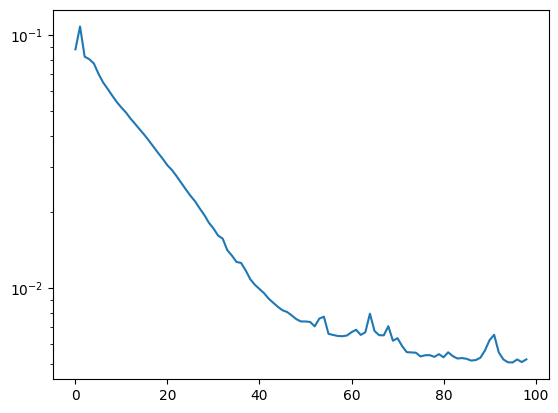

In [3]:

# %% Model
# Default model is already from the paper.
from LION.models.iterative_unrolled.LPD import LPD

default_parameters = LPD.default_parameters()
# This makes the LPD calculate the step size for the backprojection, which in my experience results in much much better pefromace
# as its all in the correct scale.
default_parameters.learned_step = True
default_parameters.step_positive = True
default_parameters.n_iters = 5
model = LPD(experiment.geometry, default_parameters)
model.cite()
model.cite("bib")

# %% Optimizer
train_param = LIONParameter()

# loss fn
loss_fcn = torch.nn.MSELoss()
train_param.optimiser = "adam"

# optimizer
train_param.epochs = 100
train_param.learning_rate = 1e-4
train_param.betas = (0.9, 0.99)
train_param.loss = "MSELoss"
optimiser = torch.optim.Adam(
    model.parameters(), lr=train_param.learning_rate, betas=train_param.betas
)

# %% Train
# create solver
solver = SupervisedSolver(
    model, optimiser, loss_fcn, verbose=True, save_folder=savefolder
)

# YOU CAN IGNORE THIS. You can 100% just write your own pytorch training loop.
# LIONSover is just a convinience class that does some stuff for you, no need to use it.

# set data
solver.set_training(lidc_dataloader)
solver.set_validation(lidc_validation, 10, validation_fname=validation_fname)
solver.set_testing(lidc_test, my_ssim)

# set checkpointing procedure
solver.set_checkpointing(
    checkpoint_fname, 10, load_checkpoint_if_exists=False, save_folder=savefolder
)
# train
solver.train(train_param.epochs)
# delete checkpoints if finished
solver.clean_checkpoints()
# save final result
solver.save_final_results(final_result_fname, savefolder)

# test

# solver.test()

plt.figure()
plt.semilogy(solver.train_loss[1:])
plt.savefig("loss.png")
